In [1]:
!hostname
# !pip install scikit-image

bell-a019.rcac.purdue.edu


In [2]:
###### This code is to track all blocking events ######
from math import pi
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
import datetime as dt
import cartopy.crs as ccrs
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import pandas as pd
import cv2
import copy
import matplotlib.path as mpath
import pickle
import glob
from netCDF4 import Dataset
from skimage import feature, segmentation, measure
from collections import defaultdict
import sys

### A function to calculate distance between two grid points on earth ###
from math import radians, cos, sin, asin, sqrt
 
def haversine(lon1, lat1, lon2, lat2): # 
    """
    Calculate the great circle distance between two points 
    on the earth (specified in decimal degrees)
    """
    # transform decimal degrees to radians
    lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])
 
    # haversine equation
    dlon = lon2 - lon1 
    dlat = lat2 - lat1 
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * asin(sqrt(a)) 
    r = 6371 # earth radius
    return c * r * 1000


In [3]:
def plotting(LWAlaweyer,lawyer,linecorr='k'):

    fig = plt.figure(figsize=[8,4])
    plt.contourf(lon,lat_NH,LWAlaweyer, 20, extend="both", cmap='Reds') 
    plt.contour(lon,lat_NH,lawyer, colors=linecorr, linewidths=1) 
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.show()

def plotting2L(LWAlaweyer,lawyer1,lawyer2,linecorr1='b',linecorr2='g'):

    fig = plt.figure(figsize=[8,4])
    plt.contourf(lon,lat_NH,LWAlaweyer, 20, extend="both", cmap='Reds') 
    plt.contour(lon,lat_NH,lawyer1, colors=linecorr1, linewidths=1) 
    plt.contour(lon,lat_NH,lawyer2, colors=linecorr2, linewidths=1)
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.show()


In [4]:
datasets = ["ERA5", "MERRA2", "JRA55"]

OUT_DIR_List = {
    "ERA5": "/scratch/bell/hu1029/LGHW/interm_ERA5",
    "MERRA2": "/scratch/bell/hu1029/LGHW/interm_MERRA2",
    "JRA55": "/scratch/bell/hu1029/LGHW/interm_JRA55"
}
yearnameList = {
    "ERA5": "1979_2021",
    "MERRA2": "1980_2021",
    "JRA55": "1979_2021"
}
timerefFile = {
    "ERA5": "/scratch/bell/hu1029/Data/processed/ERA5_Z500_6hr_1979_2021_1dg.nc",
    "MERRA2": "/scratch/bell/hu1029/Data/processed/MERRA2_Z500_6hr_1980_2021_1dg.nc",
    "JRA55": "/scratch/bell/hu1029/Data/processed/JRA55_Z500_6hr_1979_2021_1dg.nc"
}
latrefFile = {
    "ERA5": "/scratch/bell/hu1029/LGHW/interm_ERA5/ERA5_LWA_lat_1979_2021_6hr.npy",
    "MERRA2": "/scratch/bell/hu1029/LGHW/interm_MERRA2/MERRA2_LWA_lat_1980_2021_6hr.npy",
    "JRA55": "/scratch/bell/hu1029/LGHW/interm_JRA55/JRA55_LWA_lat_1979_2021_6hr.npy"
}
lonrefFile = {
    "ERA5": "/scratch/bell/hu1029/LGHW/interm_ERA5/ERA5_LWA_lon_1979_2021_6hr.npy",
    "MERRA2": "/scratch/bell/hu1029/LGHW/interm_MERRA2/MERRA2_LWA_lon_1980_2021_6hr.npy",
    "JRA55": "/scratch/bell/hu1029/LGHW/interm_JRA55/JRA55_LWA_lon_1979_2021_6hr.npy"
}
TRACK_latrefFile = {
    "ERA5": "/scratch/bell/hu1029/LGHW/interm_ERA5/ERA5_TRACK_lat_1979_2021_6hr.npy",
    "MERRA2": "/scratch/bell/hu1029/LGHW/interm_MERRA2/MERRA2_TRACK_lat_1980_2021_6hr.npy",
    "JRA55": "/scratch/bell/hu1029/LGHW/interm_JRA55/JRA55_TRACK_lat_1979_2021_6hr.npy"
}
TRACK_lonrefFile = {
    "ERA5": "/scratch/bell/hu1029/LGHW/interm_ERA5/ERA5_TRACK_lon_1979_2021_6hr.npy",
    "MERRA2": "/scratch/bell/hu1029/LGHW/interm_MERRA2/MERRA2_TRACK_lon_1980_2021_6hr.npy",
    "JRA55": "/scratch/bell/hu1029/LGHW/interm_JRA55/JRA55_TRACK_lon_1979_2021_6hr.npy"
}

In [57]:
dtname = 'JRA55'
yearname = yearnameList[dtname]
OUTDIR = OUT_DIR_List[dtname]
reflat = latrefFile[dtname]
reflon = lonrefFile[dtname]
timereff = timerefFile[dtname]

In [58]:
#%%
### Read the Z500-based LWA ###
lat = np.load(reflat)
lon = np.load(reflon)
LWA_td = np.load(f"{OUTDIR}/{dtname}_LWA_td_{yearname}_6hr.npy") 
# daily averaged data:
T = LWA_td.shape[0]
T4 = T // 4
LWA_td = LWA_td[:T4*4]
LWA_td = LWA_td.reshape(T4, 4, len(lat), len(lon)).mean(axis=1)

print(LWA_td.shape)
lat_mid = int(len(lat)/2) + 1 #91
lat_NH = lat[lat_mid:len(lat)] # NH only!
LWA_Z = LWA_td[:,lat_mid:len(lat),:] # NH only!

print(lat_NH)
print(lon)
nlon = len(lon)
nlat = len(lat)
nlat_NH =len(lat_NH)

### Time Management ###
start_year, end_year = map(int, yearname.split('_'))
Datestamp = pd.date_range(start=f"{start_year}-01-01", end=f"{end_year}-12-31")
Date0 = pd.DataFrame({'date': pd.to_datetime(Datestamp)})
Date = list(Date0['date'])
nday = len(Date)

# read the LWA_td_A and LWA_td_C 
LWA_td_A = np.load(f"{OUTDIR}/{dtname}_LWA_td_A_{yearname}_6hr.npy")
LWA_td_C = np.load(f"{OUTDIR}/{dtname}_LWA_td_C_{yearname}_6hr.npy")
# daily averaged:
T = LWA_td_A.shape[0]
T4 = T // 4
LWA_td_A = LWA_td_A[:T4*4]
LWA_td_A = LWA_td_A.reshape(T4, 4, len(lat), len(lon)).mean(axis=1)
# daily averaged:
T = LWA_td_C.shape[0]
T4 = T // 4
LWA_td_C = LWA_td_C[:T4*4]
LWA_td_C = LWA_td_C.reshape(T4, 4, len(lat), len(lon)).mean(axis=1)
# get the NH part
LWA_Z_A = LWA_td_A[:,lat_mid:len(lat),:] 
LWA_Z_C = LWA_td_C[:,lat_mid:len(lat),:] 


### Time Management ###
start_year, end_year = map(int, yearname.split('_'))
Datestamp = pd.date_range(start=f"{start_year}-01-01", end=f"{end_year}-12-31")
Date0 = pd.DataFrame({'date': pd.to_datetime(Datestamp)})
Date = list(Date0['date'])
nday = len(Date)

(15706, 181, 360)
[ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17. 18.
 19. 20. 21. 22. 23. 24. 25. 26. 27. 28. 29. 30. 31. 32. 33. 34. 35. 36.
 37. 38. 39. 40. 41. 42. 43. 44. 45. 46. 47. 48. 49. 50. 51. 52. 53. 54.
 55. 56. 57. 58. 59. 60. 61. 62. 63. 64. 65. 66. 67. 68. 69. 70. 71. 72.
 73. 74. 75. 76. 77. 78. 79. 80. 81. 82. 83. 84. 85. 86. 87. 88. 89. 90.]
[  0.   1.   2.   3.   4.   5.   6.   7.   8.   9.  10.  11.  12.  13.
  14.  15.  16.  17.  18.  19.  20.  21.  22.  23.  24.  25.  26.  27.
  28.  29.  30.  31.  32.  33.  34.  35.  36.  37.  38.  39.  40.  41.
  42.  43.  44.  45.  46.  47.  48.  49.  50.  51.  52.  53.  54.  55.
  56.  57.  58.  59.  60.  61.  62.  63.  64.  65.  66.  67.  68.  69.
  70.  71.  72.  73.  74.  75.  76.  77.  78.  79.  80.  81.  82.  83.
  84.  85.  86.  87.  88.  89.  90.  91.  92.  93.  94.  95.  96.  97.
  98.  99. 100. 101. 102. 103. 104. 105. 106. 107. 108. 109. 110. 111.
 112. 113. 114. 115. 116. 117. 118. 119. 120. 12

In [59]:
# Parameters ###
dlat = dlon = 1
BlockingDuration = 5
SeedingDuration = 3
BlockingLonWidth = 15
SeedingLonWidth = 15
valueBlockingThresh = 50  # percentile
valueSeedingThresh = 25    # percentile

Duration = BlockingDuration; LonWidth = BlockingLonWidth; ThreshPercentile =valueBlockingThresh

print('Duration:', Duration)
print('LonWidth:', LonWidth)
print('valueBlockingThresh:', ThreshPercentile)

Duration: 5
LonWidth: 15
valueBlockingThresh: 50


In [60]:

# get the clusters and connect labels across the dateline

def getConnectedLabels(LWA_Z, ThreshPercentile):

    #%% 02 Get Threshold and Duration --------------------------------
    LWA_max_lon = np.zeros((nlon*nday))
    for t in np.arange(nday):    
        for lo in np.arange(nlon):
            LWA_max_lon[t*nlon+lo] = np.max(LWA_Z[t,:,lo])
    Thresh = np.percentile(LWA_max_lon[:],ThreshPercentile)

    print('Threshold:', Thresh)

    ### Wave Event ###
    WE = np.zeros((nday,nlat_NH,nlon),dtype='uint8') 
    WE[LWA_Z>Thresh] = 255                    # Wave event

    #%% 03 connected component-labeling algorithm -----------------------
    num_labels = np.zeros(nday)
    labels = np.zeros((nday,nlat_NH,nlon))
    for d in np.arange(nday):
        num_labels[d], labels[d,:,:], stats, centroids  = cv2.connectedComponentsWithStats(WE[d,:,:], connectivity=4)

    # ------- Connect labels wrapping across the dateline (lon=0 and lon=360) -------
    labels_new = labels.copy()
    for d in range(nday):
        left  = labels_new[d, :, 0].astype(int)    # lon=0
        right = labels_new[d, :, -1].astype(int)   # lon=360

        mask = (left > 0) & (right > 0)
        if not np.any(mask):
            continue

        # pairs that need to be merged (left_label, right_label)
        pairs = np.unique(np.stack([left[mask], right[mask]], axis=1), axis=0)

        # get the minimal set of merges 
        labs = np.unique(pairs)
        rep = {int(x): int(x) for x in labs}   # initially each label represents itself

        changed = True
        while changed:
            changed = False
            # merge to the smaller label
            for a, b in pairs:
                ra, rb = rep[a], rep[b]
                r = ra if ra < rb else rb
                if rep[a] != r: rep[a] = r; changed = True
                if rep[b] != r: rep[b] = r; changed = True
            # path compression
            for x in list(rep.keys()):
                while rep[x] != rep[rep[x]]:
                    rep[x] = rep[rep[x]]

        # apply the merges
        lab = labels_new[d]
        for src, dst in rep.items():
            if src == dst: 
                continue
            lab[lab == src] = dst

        # compress labels to 1..K
        uniq = np.unique(lab); uniq = uniq[uniq > 0]
        if uniq.size > 0:
            OFFSET = 10**9
            for i, old in enumerate(uniq):
                lab[lab == old] = OFFSET + (i + 1)
            for i in range(uniq.size):
                lab[lab == OFFSET + (i + 1)] = i + 1
            num_labels[d] = uniq.size + 1  # include the background label 0

        labels_new[d] = lab

    return labels_new

connectedlabels_seeding = getConnectedLabels(LWA_Z, valueSeedingThresh)
connectedlabels_blocking = getConnectedLabels(LWA_Z, valueBlockingThresh)



Threshold: 90250740.46492662


Threshold: 136288052.29449272


In [61]:
# Parameters ###
DX_THRESH = int(18*3)
MIN_DIST = 5
TH_ABS = None

# based on the peaking value, do watershed segmentation to further split the large clusters
def group_peaks_circular_strict(peaks, dx_thresh, wrap_len, lon_col=1):
    
    K = len(peaks)
    if K == 0:
        return []
    if K == 1:
        return [np.asarray(peaks)]

    # 1) sort by lon
    order = np.argsort(peaks[:, lon_col].astype(float))
    P = peaks[order]
    lons = P[:, lon_col].astype(float)

    # 2) find the largest gap, cut the circle there
    diffs = np.diff(lons, append=lons[0] + wrap_len)   
    cut = int(np.argmax(diffs))
    P = np.concatenate([P[cut+1:], P[:cut+1]], axis=0)
    lons = P[:, lon_col].astype(float)

    # 3) unwrap, make sure lon is non-decreasing
    lons_unwrap = lons.copy()
    for i in range(1, K):
        if lons_unwrap[i] < lons_unwrap[i-1]:
            lons_unwrap[i:] += wrap_len

    # 4) greedy grouping: ensure each group's "span" <= dx_thresh
    groups = []
    start_idx = 0
    start_lon = lons_unwrap[0]
    for i in range(1, K):
        if (lons_unwrap[i] - start_lon) > dx_thresh:
            groups.append(P[start_idx:i])     # close the previous group
            start_idx = i
            start_lon = lons_unwrap[i]
    groups.append(P[start_idx:K])             # the last group

    return [np.array(g) for g in groups]

labels_final = np.zeros_like(connectedlabels_blocking, dtype=np.int32)
num_labels_final = np.zeros(nday, dtype=int)

for d in range(nday):
    lab0 = connectedlabels_blocking[d].astype(np.int32)
    field_s = LWA_Z[d].astype(float)

    next_id = 1  # 0 is the background label
    for comp_id in range(1, lab0.max() + 1):
        comp_mask = (lab0 == comp_id)
        if not np.any(comp_mask):
            continue

        # === longitude periodicity (0/360) local maxima finding ===
        # 1) 3 times tiling along lon
        F3 = np.concatenate([field_s, field_s, field_s], axis=1)
        M3 = np.concatenate([comp_mask, comp_mask, comp_mask], axis=1)
        # 2) find peaks on the 3x domain, allowing border peaks
        peaks3 = feature.peak_local_max(
            F3,
            min_distance=MIN_DIST,
            threshold_abs=(TH_ABS if TH_ABS is not None else None),
            labels=M3,
            exclude_border=False
        )
        # 3) keep only the "middle" peaks, map lon back to original domain
        if peaks3.size == 0:
            peaks = peaks3
        else:
            yy3 = peaks3[:, 0]
            xx3 = peaks3[:, 1]
            keep = (xx3 >= nlon) & (xx3 < 2*nlon)
            peaks = np.stack([yy3[keep], (xx3[keep] - nlon)], axis=1).astype(int)
            # 4) delete repeated peaks
            if peaks.size:
                peaks = np.unique(peaks, axis=0)

        if len(peaks) <= 1:
            # if no peaks or only 1 peak, do not cut
            labels_final[d][comp_mask] = next_id
            next_id += 1
            continue

        # group peaks by longitude distance
        groups = group_peaks_circular_strict(
            peaks=peaks,
            dx_thresh=DX_THRESH,
            wrap_len=nlon,  
            lon_col=1
        )

        if len(groups) == 1:
            labels_final[d][comp_mask] = next_id
            next_id += 1
            continue

        # pick one representative peak (the strongest) from each group as marker
        markers = np.zeros_like(lab0, dtype=np.int32)
        for k, grp in enumerate(groups, start=1):
            vals = [field_s[lat_i, lon_i] for (lat_i, lon_i) in grp]
            lat_i, lon_i = grp[int(np.argmax(vals))]
            markers[lat_i, lon_i] = k

        # masked watershed segmentation, do the watershed on -field_s
        # 1) 3 times tiling along lon
        F3 = np.concatenate([field_s, field_s, field_s], axis=1)
        M3 = np.concatenate([comp_mask, comp_mask, comp_mask], axis=1)
        # 2) only keep markers on the middle copy
        markers3 = np.zeros_like(M3, dtype=np.int32)
        yy, xx = np.where(markers > 0)
        markers3[yy, xx] = markers[yy, xx]
        markers3[yy, xx + nlon] = markers[yy, xx]
        markers3[yy, xx + 2*nlon] = markers[yy, xx]
        # 3) watershed on the 3x domain
        ws3 = segmentation.watershed(-F3, markers=markers3, mask=M3)
        # 4) cut the region
        ws = ws3[:, nlon:2*nlon].astype(np.int32)

        # write to final labels, re-assign IDs
        for k in range(1, ws.max() + 1):
            submask = (ws == k)
            if np.any(submask):
                labels_final[d][submask] = next_id
                next_id += 1

    num_labels_final[d] = labels_final[d].max()  # not include the background label 0

labels_blocking_watershed = labels_final


In [62]:
#%% 04 Get the maximum LWA location of each individule event and it's area and width --------------

def getClusterFeature(labels_new, LonWidth):

    lat_d = []; lon_d = []
    lon_w = []; lon_e = []; lon_wide = []
    labelx = []

    for d in np.arange(nday):

        # get the label values in this day
        labelvalue = np.unique(labels_new[d])
        labelvalue = labelvalue[labelvalue>0]

        if len(labelvalue)==0:
            lat_d.append([]); lon_d.append([])
            lon_w.append([]); lon_e.append([]); lon_wide.append([])
            labelx.append([])
            continue
        
        lat_list=[]; lon_list=[]
        lon_w_list=[]; lon_e_list=[]; lon_wide_list=[]
        label_list = []

        for n in np.arange(0,len(labelvalue)):

            lbv = labelvalue[n]
            LWA_d = np.zeros((nlat_NH, nlon))
            LWA_d[labels_new[d]==lbv]=LWA_Z[d][labels_new[d]==lbv]   ### isolate that wave event ###
            ### Get the maximum location, always get the first point ###
            ix, iy = np.argwhere(LWA_d == LWA_d.max())[0]  # get the maximum location
            
            ### Get the west east boundary longitude ###
            ixs, iys = np.where(labels_new[d]==lbv)
            lon_vals = np.sort(lon[iys] % 360)
            # calculate the width considering periodic boundary
            gaps = np.diff(np.r_[lon_vals, lon_vals[0] + 360])
            k = np.argmax(gaps)
            # the point after the largest gap is the west boundary
            # the point before the largest gap is the east boundary
            lon_w_i = lon_vals[(k+1) % lon_vals.size]
            lon_e_i = lon_vals[k]
            width = 360 - gaps[k]

            #%% 04 Single Event Filtering ---------------------------------
            if (abs(lat_NH[ix]) < 30) or (width < LonWidth): #or (width > 120):
                labels_new[d][labels_new[d]==lbv] = 0
                continue
            else:
                lat_list.append(lat_NH[ix])
                lon_list.append(lon[iy])
                lon_w_list.append(float(lon_w_i))
                lon_e_list.append(float(lon_e_i))
                lon_wide_list.append(float(width))
                label_list.append(lbv)

        lat_d.append(lat_list);   lon_d.append(lon_list)
        lon_w.append(lon_w_list); lon_e.append(lon_e_list)
        lon_wide.append(lon_wide_list)
        labelx.append(label_list)

    print('Identify 2: single event Feature Get done')
    return lat_d, lon_d, lon_w, lon_e, lon_wide, labelx, labels_new

lat_d, lon_d, lon_w, lon_e, lon_wide, labelx, labels_blocking_filtered = getClusterFeature(labels_blocking_watershed, BlockingLonWidth)



Identify 2: single event Feature Get done


In [63]:
def plottingCenter(LWAlaweyer, lawyer1, lawyer2, lat_pts1, lon_pts1, lat_pts2, lon_pts2, col1='green', col2='blue'):

    fig = plt.figure(figsize=[8,4])
    plt.contourf(lon,lat_NH,LWAlaweyer, 20, extend="both", cmap='Reds') 
    plt.contour(lon,lat_NH,lawyer1, colors=col1, linewidths=1)
    plt.contour(lon,lat_NH,lawyer2,colors=col2, linewidths=1)
    plt.scatter(lon_pts1, lat_pts1, s=12, marker='^', color=col1)
    plt.scatter(lon_pts2, lat_pts2, s=10, marker='+', color=col2) 

    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.show()
    
day = 0
print(lat_d[day], lon_d[day], lon_w[day], lon_e[day], lon_wide[day], labelx[day])


[np.float64(63.0), np.float64(70.0), np.float64(75.0)] [np.float64(170.0), np.float64(226.0), np.float64(97.0)] [144.0, 127.0, 46.0] [192.0, 8.0, 126.0] [48.0, 241.0, 80.0] [np.int32(1), np.int32(2), np.int32(3)]


In [64]:
#%% 06 Pairing events during consecutive two days  (with the shortest dististance) --------

def pair2days(lat_d, lon_d):
    ########### the distance is limited to 18 degree longitude and 13.5 degree latitude #########
    next_index = [] # for each label cluster in day d, store the index of its pair in day d+1, if no pair, then nan
    lon_thresh = 18
    lat_thresh = 13.5
    for d in np.arange(nday-1):
        next_index_day = np.full(len(lon_d[d]), np.nan)
        ### create a matrix that contains the distance between each WE during the consective two days ###
        shift_L = np.zeros((len(lon_d[d]),len(lon_d[d+1]) ))
        for i in np.arange(len(lon_d[d])):
            for j in np.arange(len(lon_d[d+1])):
                shift_L[i,j] = haversine(lon_d[d][i], lat_d[d][i], lon_d[d+1][j], lat_d[d+1][j])    

        ### pair the events from the shortest distance among them ###
        for dd in np.arange( min(len(lon_d[d]), len(lon_d[d+1])) ):
            WE_i, WE_j = np.unravel_index(np.argmin(shift_L), shift_L.shape)

            ### note the distance between two paris is also limited a thrshold ###
            # lon_shift = abs(lon_d[d+1][WE_j] - lon_d[d][WE_i])
            # lat_shift = abs(lat_d[d+1][WE_j] - lat_d[d][WE_i])
            # ### correct the longitude shift due the periodic boundary ###        
            # if lon_shift > 180:
            #     lon_shift = lon_shift-360
            # if lon_shift < -180:
            #     lon_shift = lon_shift + 360
            delta = ( (lon_d[d+1][WE_j] - lon_d[d][WE_i] + 540) % 360 ) - 180
            lon_shift = abs(delta)
            lat_shift = abs(lat_d[d+1][WE_j] - lat_d[d][WE_i])
            
            if lon_shift<lon_thresh and lat_shift<lat_thresh:
                next_index_day[WE_i] = WE_j  ### these two events can be paired! ###
                shift_L[WE_i, :] = np.inf    ### make the distance related to these two events to infinity so that we can search the next shortest distance and avoid this pair ###
                shift_L[:, WE_j] = np.inf
            else:
                shift_L[WE_i, :] = np.inf
                shift_L[:, WE_j] = np.inf
                
        next_index.append(next_index_day)

    print('Identify 3: distance filter done -------------- ')
    return next_index

next_index_blocking = pair2days(lat_d, lon_d)

print('blocking paired index:')
print(next_index_blocking[100])


Identify 3: distance filter done -------------- 
blocking paired index:
[ 1. nan  3.]


In [65]:
lat_d_0 = copy.deepcopy(lat_d)
lon_d_0 = copy.deepcopy(lon_d)

def trackBlocking(lat_d, lon_d, lon_wide, labelx, next_index, labels_new, Duration, stationary=True):

    lon_thresh = 18
    lat_thresh = 13.5

    #%% 07 Tracking Wave Events ---------------------------------
    B_freq = np.zeros((nlat_NH, nlon))         ### The final blocking frequency/total number 
    B_freq2 = np.zeros((nday ,nlat_NH, nlon))  ### Record whether a grid point is under a blocking for a certain day (only 1 and 0 in this 3D array)

    ########### Now we begin to track wave events #########
    Blocking_lat = []; Blocking_lon = []; Blocking_date = []
    Blocking_lon_wide = []; Blocking_area = []; Blocking_label = []
            
    for d in np.arange(nday-1):
        ### if all wave events within this day are tracked, then go to the next day ###
        if len(lon_d[d]) == 0:
            continue
                
        for i in np.arange(len(lon_d[d])):

            lbv = labelx[d][i]
            ### if this wave evnet is tracked, then go to the next wave event ###
            if np.isnan(lon_d[d][i]):
                continue

            ### tracking starts ###
            day = 0
            track_lon = []; track_lat = []; track_date = []
            track_lon_index = []; track_lat_index = []
            track_lon_wide = []; track_area = []; track_lat_wide = []; track_label = []
            B_count = np.zeros((nlat_NH, nlon))
            B = np.zeros((nlat_NH, nlon))
            B_count2 = []
            
            B_count[labels_new[d+day]==lbv]+=1
            B[labels_new[d+day]==lbv]=1            
            B_count2.append(B)
            
            track_lon.append(lon_d[d+day][i]); track_lon_index.append(i)               
            track_lat.append(lat_d[d+day][i]); track_lat_index.append(i)            
            track_date.append(Date[d+day])
            track_lon_wide.append(lon_wide[d+day][i])
            track_label.append(labels_new[d+day]==lbv)
            
            next_index_pair= next_index[d+day][i] ### find the pair event at next day, it could be nan ### the i-th event at day d -> j-th the next day
            
            if ~np.isnan(next_index_pair):
                next_index_pair = int(next_index_pair) # the index of the cluster at the next day
                
            # while ~np.isnan(next_index_pair) and abs(lon_d[d+day+1][next_index_pair]-track_lon[0]) < 1.5*18 and abs(lat_d[d+day+1][next_index_pair]-track_lat[0]) < 1.5*13.5:
            while ~np.isnan(next_index_pair):
                if stationary:
                    # —— compare with the initial point ——
                    lon_diff0 = ((lon_d[d+day+1][next_index_pair] - track_lon[0] + 540) % 360) - 180
                    lat_diff0 =  (lat_d[d+day+1][next_index_pair] - track_lat[0])
                    if (abs(lon_diff0) >= 1.5*lon_thresh) or (abs(lat_diff0) >= 1.5*lat_thresh):
                        break   

                ### if this event does have a pair next day, and the displacement is within 1.5*18 lons and 1.5*13.5 lats, then keep tracking ###
                nextpair_label = labelx[d+day+1][next_index_pair] # the label value of that cluster at the next day
                track_date.append(Date[d+day+1])
                B_count[labels_new[d+day+1]==nextpair_label]+=1
                B = np.zeros((nlat_NH, nlon))
                B[labels_new[d+day+1]==nextpair_label]=1            
                B_count2.append(B)
                    
                track_lon.append(lon_d[d+day+1][next_index_pair])
                track_lon_index.append(next_index_pair)
                track_lat.append(lat_d[d+day+1][next_index_pair])
                track_lat_index.append(next_index_pair)
                track_lon_wide.append(lon_wide[d+day+1][next_index_pair])
                track_label.append(labels_new[d+day+1]==nextpair_label)
                
                ### interate the day ###
                day+=1
                
                ### if this the last day, then jump out ###
                if d+day+1>nday-1:
                    break
                
                ### if not, then find a next pair ###
                next_index_pair = next_index[d+day][next_index_pair]
                if ~np.isnan(next_index_pair):
                    next_index_pair = int(next_index_pair)
            
            ### when there are no pair events in the next day, the track is end ###
            ### make sure the wave event is large enough ###
            if day+1 >= Duration:
                Blocking_lon.append(track_lon)
                Blocking_lat.append(track_lat)
                Blocking_date.append(track_date)
                Blocking_label.append(track_label)
                B_freq += B_count
                for dd in np.arange(len(B_count2)):
                    B_freq2[d+dd,:,:]+= B_count2[dd]
            
            ### Once we successfully detected a wave event, we mark that with nan to avoid repeating ###
            for dd in np.arange(day+1):
                lon_d[d+dd][track_lon_index[dd]] = np.nan
                lat_d[d+dd][track_lat_index[dd]] = np.nan
        
        if d % 1000 == 0:
            print('day', d, flush=True)

    print('Identify 4: event tracking done')

    return Blocking_lat, Blocking_lon, Blocking_date, Blocking_label, B_freq, B_freq2

Blocking_lat, Blocking_lon, Blocking_date, Blocking_label, B_freq, B_freq2 = trackBlocking(lat_d, lon_d, lon_wide, labelx, next_index_blocking, labels_blocking_filtered, Duration=1, stationary=True)



day 0
day 1000
day 2000
day 3000
day 4000
day 5000
day 6000
day 7000
day 8000
day 9000
day 10000
day 11000
day 12000
day 13000
day 14000
day 15000
Identify 4: event tracking done


In [66]:

#%% 08 get the blocking peaking date and location and wave activity -----------------
Blocking_peaking_date = []
Blocking_peaking_date_index = []
Blocking_peaking_lon = []
Blocking_peaking_lat = []

for n in np.arange(len(Blocking_date)):
    start = Date.index(Blocking_date[n][0])
    end = Date.index(Blocking_date[n][-1])
    duration = len(Blocking_date[n])
    LWA_event_max = np.zeros((duration))

    for d in np.arange(duration):
        index = start+d
        lo = np.squeeze(np.array(np.where( lon == Blocking_lon[n][d])))
        la = np.squeeze(np.array(np.where( lat_NH == Blocking_lat[n][d])))    
        LWA_event_max[d]  = LWA_Z[index, la, lo]
    
    Blocking_peaking_date_index=int(np.squeeze(np.array(np.where( LWA_event_max==np.max(LWA_event_max) ))))
    Blocking_peaking_date.append(Blocking_date[n][Blocking_peaking_date_index])
    Blocking_peaking_lon.append(Blocking_lon[n][Blocking_peaking_date_index])
    Blocking_peaking_lat.append(Blocking_lat[n][Blocking_peaking_date_index])

print('Identify 5: peaking date and location done')

# %% 09 get the blocking types -----------------
# separate 3 types of blocks (ridge, trough, dipole) 
# Method: Focus on the peaking date, calculate the total LWA_AC and LWA_C of the block region 
BlockingTypeI = []
lat_range=int(int((90-np.max(Blocking_peaking_lat))/dlat)*2+1)
lon_range=int(30/dlon)+1

for n in np.arange(len(Blocking_lon)):

    LWA_AC_sum = 0
    LWA_C_sum = 0
    Blocking_A = []
    Blocking_C = []
        
    ### peaking date information ###
    peaking_date_index = Date.index(Blocking_peaking_date[n])
    peaking_lon_index = np.squeeze(np.array(np.where( lon[:]==Blocking_peaking_lon[n])))
    peaking_lat_index = np.squeeze(np.array(np.where( lat_NH[:]==Blocking_peaking_lat[n]))) 
    
    t = np.squeeze(np.where(np.array(Blocking_date[n]) == np.array(Blocking_peaking_date[n] )))
    
    LWA_max = LWA_Z[peaking_date_index,peaking_lat_index,peaking_lon_index]

    ### date LWA_AC and  date LWA_C ###
    LWA_AC  = LWA_Z_A[peaking_date_index,:,:]
    LWA_C  = LWA_Z_C[peaking_date_index,:,:]
    
    ### shift the field to make the block center location at the domain center ###
    LWA_AC = np.roll(LWA_AC, int(nlon/2)-peaking_lon_index, axis=1)
    LWA_C = np.roll(LWA_C,   int(nlon/2)-peaking_lon_index, axis=1)
    WE = np.roll(Blocking_label[n][t], int(nlon/2)-peaking_lon_index, axis=1)
    lon_roll = np.roll(lon,   int(nlon/2)-peaking_lon_index)

    LWA_AC = LWA_AC[  :, int(nlon/2)-int(lon_range/2):int(nlon/2)+int(lon_range/2)+1]
    LWA_C = LWA_C[    :, int(nlon/2)-int(lon_range/2):int(nlon/2)+int(lon_range/2)+1]
    WE = WE[   :, int(nlon/2)-int(lon_range/2):int(nlon/2)+int(lon_range/2)+1]       ### Note that we need to confine the blocking region to +-15 degrees
    
    LWA_AC_d = np.zeros((nlat_NH, lon_range))
    LWA_C_d = np.zeros((nlat_NH, lon_range))
    LWA_AC_d[WE == True]  = LWA_AC[WE== True]
    LWA_C_d[WE == True]  =  LWA_C[WE == True]
    
    LWA_AC_sum += LWA_AC_d.sum()
    LWA_C_sum += LWA_C_d.sum()
    Blocking_A.append(LWA_AC_d.sum())
    Blocking_C.append(LWA_C_d.sum())

    ### if the anticyclonic LWA is much stronger than cytclonic LWA, then it is defined as ridge ###
    ### if the anticyclonic LWA is comparable with cyclonic LWA, then it is defined as dipole ###
    ### if the anticyclonic LWA is weaker than cyclonic LWA, then it is defined as trough events ###
    
    if LWA_AC_sum > 10 * LWA_C_sum :
        BlockingTypeI.append(1)  # 1 for ridge
    elif LWA_C_sum > 2 * LWA_AC_sum:
        BlockingTypeI.append(2)  # 2 for trough
    else:
        BlockingTypeI.append(3)  # 3 for dipole

    print(n)

print(len(BlockingTypeI))

Identify 5: peaking date and location done
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266

In [67]:
print(len(BlockingTypeI))

20042


In [68]:
BlockingTotal_date = Blocking_date
BlockingTotal_label = Blocking_label
Blocking_freq = B_freq
Blocking_freq2 = B_freq2

In [69]:
# BlockingTotal_date: only select BlockingTypeI == 1
BlockingTotal_date_ridge = [BlockingTotal_date[i] for i in range(len(BlockingTypeI)) if BlockingTypeI[i] == 1]
BlockingTotal_label_ridge = [BlockingTotal_label[i] for i in range(len(BlockingTypeI)) if BlockingTypeI[i] == 1]

In [70]:
print(len(BlockingTotal_date))
print(len(BlockingTotal_date_ridge))

20042
6666


## e-log Histogram, for all the blocking cluster events over the NH, and the normal histogram

6666 blocking events in total
[6, 3, 3, 6, 1, 2, 2, 3, 1, 2]


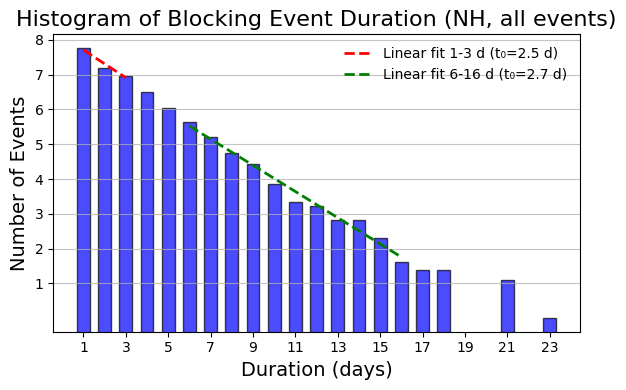

In [71]:
import numpy as np
import matplotlib.pyplot as plt

# find the duration of each blocking event and make the histogram of it
blkduration = [len(dates) for dates in BlockingTotal_date_ridge]
print(len(blkduration), 'blocking events in total')
print(blkduration[:10])
blkduration = np.array(blkduration)

# --- histogram ---
plt.figure(figsize=(6,4))
plt.hist(blkduration, bins=np.arange(1, blkduration.max()+2)-0.5,
         alpha=0.7, color='blue', edgecolor='black', rwidth=0.6)
plt.xticks(np.arange(1, blkduration.max()+1, 2))
plt.xlabel('Duration (days)', fontsize=14)
plt.ylabel('Number of Events', fontsize=14)
plt.title('Histogram of Blocking Event Duration (NH, all events)', fontsize=16)
plt.yscale('log', base=np.e)

ytop = plt.gca().get_ylim()[1]
yticks = np.arange(1, int(np.ceil(np.log(ytop)))+1)
plt.yticks(np.exp(yticks), yticks)

plt.grid(axis='y', alpha=0.75)

ax = plt.gca()

# --- count ---
blkduration = np.asarray(blkduration, dtype=int)
max_d = blkduration.max()
counts_all = np.bincount(blkduration, minlength=max_d+1) 
durations = np.arange(1, max_d+1)          
counts = counts_all[1:]                    

def fit_and_plot(dmin, dmax, color, label_prefix):

    sel = (durations >= dmin) & (durations <= dmax)
    x = durations[sel]
    y = counts[sel]
    m = y > 0
    x = x[m]; y = y[m]
    if x.size < 2:
        return  

    b, a = np.polyfit(x, np.log(y), 1)  # return [slope, intercept] -> b, a

    # plot a line segment
    xfit = np.array([dmin, dmax], dtype=float)
    yfit = np.exp(a + b * xfit)

    ax.plot(xfit, yfit, '--', lw=2, color=color,
            label=f'{label_prefix} {dmin}-{dmax} d (t₀={-1.0/b:.1f} d)')

fit_and_plot(1, 3,  'red',   'Linear fit')
fit_and_plot(6, 16, 'green', 'Linear fit')

ax.legend(frameon=False, fontsize=10, loc='best')

plt.tight_layout()
plt.show()

6666 blocking events in total
[6, 3, 3, 6, 1, 2, 2, 3, 1, 2]


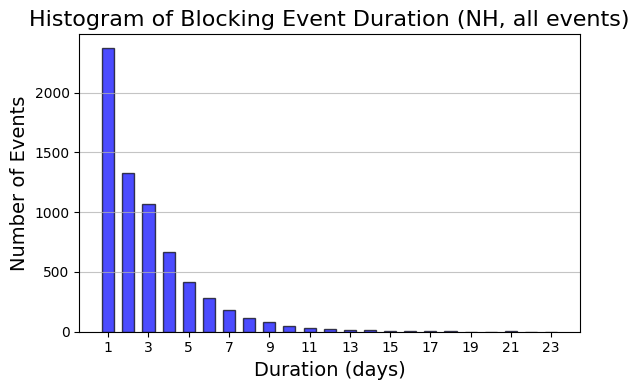

In [72]:
# find the duration of each blocking event and make the histogram of it
blkduration = [len(dates) for dates in BlockingTotal_date_ridge]
print(len(blkduration), 'blocking events in total')
print(blkduration[:10])
blkduration = np.array(blkduration)
# make the histogram of event persistence, 1 day per bin, y-axis is number of events (linear scale)
plt.figure(figsize=(6,4))
plt.hist(blkduration, bins=np.arange(1, blkduration.max()+2)-0.5, alpha=0.7, color='blue', edgecolor='black', rwidth=0.6)
plt.xticks(np.arange(1, blkduration.max()+1, 2))
plt.xlabel('Duration (days)', fontsize=14)
plt.ylabel('Number of Events', fontsize=14)
plt.title(f'Histogram of Blocking Event Duration (NH, all events)', fontsize=16)
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()


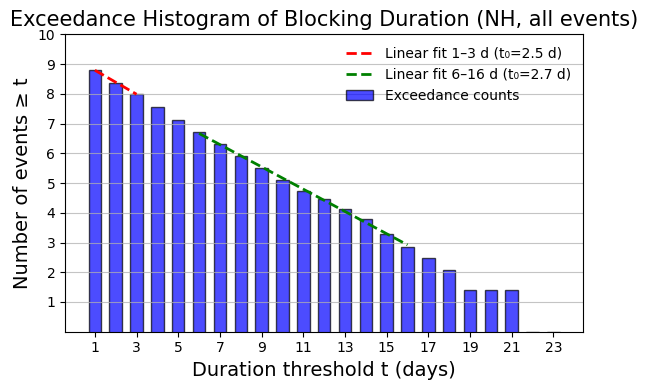

In [73]:
# the exceedance histogram
plt.figure(figsize=(6,4))

# ---------- Exceedance histogram ----------
sectordurationList = blkduration
max_d = sectordurationList.max()

# exceedance counts: N(t) = number of events with duration >= t
durations = np.arange(1, max_d + 1)
counts = np.array([np.sum(sectordurationList >= t) for t in durations])

plt.bar(durations, counts, width=0.6, alpha=0.7,
        color='blue', edgecolor='black', label='Exceedance counts')

plt.xticks(np.arange(1, max_d+1, 2))
plt.xlabel('Duration threshold t (days)', fontsize=14)
plt.ylabel('Number of events ≥ t', fontsize=14)
plt.title('Exceedance Histogram of Blocking Duration (NH, all events)', fontsize=15)

# ---------- log-e y-axis ----------
ax = plt.gca()
ax.set_yscale('log', base=np.e)
ax.set_ylim(bottom=1)

ytop = ax.get_ylim()[1]
kmax = int(np.ceil(np.log(ytop)))
yticks = np.exp(np.arange(1, kmax + 1))
ax.set_yticks(yticks)
ax.set_yticklabels(np.arange(1, kmax + 1))  # show ln(N)
plt.grid(axis='y', alpha=0.75, which='both')

# ---------- Linear-fit segments ----------
def fit_and_plot(dmin, dmax, color, label_prefix):
    sel = (durations >= dmin) & (durations <= dmax)
    x = durations[sel]
    y = counts[sel]
    m = y > 0
    x = x[m]; y = y[m]
    if x.size < 2:
        return
    b, a = np.polyfit(x, np.log(y), 1)  # ln-space linear fit
    xfit = np.array([dmin, dmax], dtype=float)
    yfit = np.exp(a + b * xfit)
    ax.plot(xfit, yfit, '--', lw=2, color=color,
            label=f'{label_prefix} {dmin}–{dmax} d (t₀={-1.0/b:.1f} d)')

fit_and_plot(1, 3,  'red',   'Linear fit')
fit_and_plot(6, 16, 'green', 'Linear fit')

ax.legend(frameon=False, fontsize=10, loc='best')
plt.tight_layout()
plt.show()

## Define the 45-65 blocking, based on the cluster events, e-log and the longitudinal distribution

In [74]:
# # define the 'sector blocking' (use lat = 45-65 as the range limitation)
# sectorduration = []
# for k in np.arange(len(BlockingTotal_label_ridge)):
#     sectorlen = 0
#     for d in np.arange(len(BlockingTotal_label_ridge[k])):
#         lb = BlockingTotal_label_ridge[k][d]
#         # compress to 1d, considering only the lat range 45-65N
#         lat_inds = np.where((lat_NH >= 45) & (lat_NH <= 65))[0]
#         lb = lb[lat_inds, :]
#         # if the length of lat_inds > 0 is larger than 10, then consider it as a sector blocking
#         lon_inds = np.where(np.any(lb > 0, axis=0))[0] # find the lon indices that have blocked over this lat range
#         # lon_inds = np.where(np.nansum(lb, axis=0) > 10)[0] # find the lon indices that have blocked over this lat range
    
#         # focus on lat range 45-65N, if the labels = 1 covers more than 15 lon degrees, then define it as a sector blocking
#         if len(lon_inds) >= 15:
#             sectorlen+=1
#     # sectorlen is the final duration of this new defined sector blocking event
#     sectorduration.append(sectorlen)
# sectorduration = np.array(sectorduration)

# blkduration = sectorduration
# # --- histogram ---
# plt.figure(figsize=(6,4))
# plt.hist(blkduration, bins=np.arange(1, blkduration.max()+2)-0.5,
#          alpha=0.7, color='blue', edgecolor='black', rwidth=0.6)
# plt.xticks(np.arange(1, blkduration.max()+1, 2))
# plt.xlabel('Duration (days)', fontsize=14)
# plt.ylabel('Number of Events', fontsize=14)
# plt.title('Histogram of Blocking Event Duration (NH, 45-65N)', fontsize=16)
# plt.yscale('log', base=np.e)

# ytop = plt.gca().get_ylim()[1]
# yticks = np.arange(1, int(np.ceil(np.log(ytop)))+1)
# plt.yticks(np.exp(yticks), yticks)

# plt.grid(axis='y', alpha=0.75)

# ax = plt.gca()

# # --- count ---
# blkduration = np.asarray(blkduration, dtype=int)
# max_d = blkduration.max()
# counts_all = np.bincount(blkduration, minlength=max_d+1) 
# durations = np.arange(1, max_d+1)          
# counts = counts_all[1:]                    

# def fit_and_plot(dmin, dmax, color, label_prefix):

#     sel = (durations >= dmin) & (durations <= dmax)
#     x = durations[sel]
#     y = counts[sel]
#     m = y > 0
#     x = x[m]; y = y[m]
#     if x.size < 2:
#         return  

#     b, a = np.polyfit(x, np.log(y), 1)  # return [slope, intercept] -> b, a

#     # plot a line segment
#     xfit = np.array([dmin, dmax], dtype=float)
#     yfit = np.exp(a + b * xfit)

#     ax.plot(xfit, yfit, '--', lw=2, color=color,
#             label=f'{label_prefix} {dmin}-{dmax} d (t₀={-1.0/b:.1f} d)')

# fit_and_plot(1, 3,  'red',   'Linear fit')
# fit_and_plot(6, 16, 'green', 'Linear fit')

# ax.legend(frameon=False, fontsize=10, loc='best')

# plt.tight_layout()
# plt.show()

In [75]:
# plot the annual mean blocking frequency at each longitude to compare

# # compress the blocking frequency to 2D (day, lon), by compressing the lat dimension (only take 45-65N)
# lat_inds = np.where((lat_NH >= 45) & (lat_NH <= 65))[0]
# Blocking_freq2_compressed = np.any(Blocking_freq2_ridge[:, lat_inds, :], axis=1).astype(float)
# print(np.shape(Blocking_freq2_compressed))
# # calculate the annual mean blocking frequency at each longitude
# Blocking_freq_mean = np.nansum(Blocking_freq2_compressed, axis=0) / nday
# print(np.shape(Blocking_freq_mean))
# print(Blocking_freq_mean.max())
# # make a plot
# plt.figure(figsize=(10,4))
# plt.plot(lon, Blocking_freq_mean, color='blue', lw=2)
# plt.xlim(0, 360)
# plt.xticks(np.arange(0, 361, 30))
# plt.xlabel('Longitude', fontsize=14)
# plt.ylabel('Annual Mean Blocking Frequency\n(45-65N)', fontsize=14)
# plt.title('Annual Mean Blocking Frequency along Longitude (45-65N)', fontsize=16)
# plt.grid(axis='y', alpha=0.75)
# plt.tight_layout()
# plt.show()

In [76]:
# # the exceedance histogram
# plt.figure(figsize=(6,4))

# # ---------- Exceedance histogram ----------
# sectordurationList = blkduration
# max_d = sectordurationList.max()

# # exceedance counts: N(t) = number of events with duration >= t
# durations = np.arange(1, max_d + 1)
# counts = np.array([np.sum(sectordurationList >= t) for t in durations])

# plt.bar(durations, counts, width=0.6, alpha=0.7,
#         color='blue', edgecolor='black', label='Exceedance counts')

# plt.xticks(np.arange(1, max_d+1, 2))
# plt.xlabel('Duration threshold t (days)', fontsize=14)
# plt.ylabel('Number of events ≥ t', fontsize=14)
# plt.title('Exceedance Histogram of Blocking Duration (NH, 45–65°N)', fontsize=15)

# # ---------- log-e y-axis ----------
# ax = plt.gca()
# ax.set_yscale('log', base=np.e)
# ax.set_ylim(bottom=1)

# ytop = ax.get_ylim()[1]
# kmax = int(np.ceil(np.log(ytop)))
# yticks = np.exp(np.arange(1, kmax + 1))
# ax.set_yticks(yticks)
# ax.set_yticklabels(np.arange(1, kmax + 1))  # show ln(N)
# plt.grid(axis='y', alpha=0.75, which='both')

# # ---------- Linear-fit segments ----------
# def fit_and_plot(dmin, dmax, color, label_prefix):
#     sel = (durations >= dmin) & (durations <= dmax)
#     x = durations[sel]
#     y = counts[sel]
#     m = y > 0
#     x = x[m]; y = y[m]
#     if x.size < 2:
#         return
#     b, a = np.polyfit(x, np.log(y), 1)  # ln-space linear fit
#     xfit = np.array([dmin, dmax], dtype=float)
#     yfit = np.exp(a + b * xfit)
#     ax.plot(xfit, yfit, '--', lw=2, color=color,
#             label=f'{label_prefix} {dmin}–{dmax} d (t₀={-1.0/b:.1f} d)')

# fit_and_plot(1, 3,  'red',   'Linear fit')
# fit_and_plot(6, 16, 'green', 'Linear fit')

# ax.legend(frameon=False, fontsize=10, loc='best')
# plt.tight_layout()
# plt.show()

## The 6-sector blocking defined on blocking cluster, e-log and normal histogram

In [77]:
# # get the sector blocking duration histogram
# sectorlon = [(270, 360), (0, 45), (45, 120), (90, 150), (150, 225), (210, 270)] # 6 regions

# sectordurationList = []
# for n in np.arange(len(sectorlon)):

#     sectorduration = []
#     for k in np.arange(len(BlockingTotal_label_ridge)):
#         sectorlen = 0
#         for d in np.arange(len(BlockingTotal_label_ridge[k])):
#             lb = BlockingTotal_label_ridge[k][d]
#             # compress to 1d, considering only the lat range 45-65N
#             lat_inds = np.where((lat_NH >= 45) & (lat_NH <= 65))[0]
#             lon_inds = np.where((lon >= sectorlon[n][0]) & (lon <= sectorlon[n][1]))[0]
#             lb = lb[lat_inds, :]
#             lb = lb[:, lon_inds]
#             # if the length of lat_inds > 0 is larger than 10, then consider it as a sector blocking
#             lon_inds = np.where(np.any(lb > 0, axis=0))[0] # find the lon indices that have blocked over this lat range
#             # lon_inds = np.where(np.nansum(lb, axis=0) > 10)[0] # find the lon indices that have blocked over this lat range
        
#             # focus on lat range 45-65N, if the labels = 1 covers more than 15 lon degrees, then define it as a sector blocking
#             if len(lon_inds) >= 15:
#                 sectorlen+=1
#         # sectorlen is the final duration of this new defined sector blocking event
#         sectorduration.append(sectorlen)
#     print(sectorduration)
#     sectordurationList.extend(sectorduration)

# sectordurationList = np.array(sectordurationList)

# blkduration = sectordurationList
# # --- histogram ---
# plt.figure(figsize=(6,4))
# plt.hist(blkduration, bins=np.arange(1, blkduration.max()+2)-0.5,
#          alpha=0.7, color='blue', edgecolor='black', rwidth=0.6)
# plt.xticks(np.arange(1, blkduration.max()+1, 2))
# plt.xlabel('Duration (days)', fontsize=14)
# plt.ylabel('Number of Events', fontsize=14)
# plt.title('Histogram of Blocking Event Duration (NH, 45-65N, 6 sectors)', fontsize=16)
# plt.yscale('log', base=np.e)

# ytop = plt.gca().get_ylim()[1]
# yticks = np.arange(1, int(np.ceil(np.log(ytop)))+1)
# plt.yticks(np.exp(yticks), yticks)

# plt.grid(axis='y', alpha=0.75)

# ax = plt.gca()

# # --- count ---
# blkduration = np.asarray(blkduration, dtype=int)
# max_d = blkduration.max()
# counts_all = np.bincount(blkduration, minlength=max_d+1) 
# durations = np.arange(1, max_d+1)          
# counts = counts_all[1:]                    

# def fit_and_plot(dmin, dmax, color, label_prefix):

#     sel = (durations >= dmin) & (durations <= dmax)
#     x = durations[sel]
#     y = counts[sel]
#     m = y > 0
#     x = x[m]; y = y[m]
#     if x.size < 2:
#         return  

#     b, a = np.polyfit(x, np.log(y), 1)  # return [slope, intercept] -> b, a

#     # plot a line segment
#     xfit = np.array([dmin, dmax], dtype=float)
#     yfit = np.exp(a + b * xfit)

#     ax.plot(xfit, yfit, '--', lw=2, color=color,
#             label=f'{label_prefix} {dmin}-{dmax} d (t₀={-1.0/b:.1f} d)')

# fit_and_plot(1, 3,  'red',   'Linear fit')
# fit_and_plot(6, 16, 'green', 'Linear fit')

# ax.legend(frameon=False, fontsize=10, loc='best')

# plt.tight_layout()
# plt.show()


# # make the histogram of event persistence, 1 day per bin, y-axis is number of events (linear scale)
# plt.figure(figsize=(6,4))
# plt.hist(blkduration, bins=np.arange(1, blkduration.max()+2)-0.5, alpha=0.7, color='blue', edgecolor='black', rwidth=0.6)
# plt.xticks(np.arange(1, blkduration.max()+1, 2))
# plt.xlabel('Duration (days)', fontsize=14)
# plt.ylabel('Number of Events', fontsize=14)
# plt.title(f'Histogram of Blocking Event Duration (NH, 45-65N, 6 sectors)', fontsize=16)
# plt.grid(axis='y', alpha=0.75)
# plt.tight_layout()
# plt.show()


In [78]:
# plt.figure(figsize=(6,4))

# # ---------- Exceedance histogram ----------
# max_d = blkduration.max()

# # exceedance counts: N(t) = number of events with duration >= t
# durations = np.arange(1, max_d + 1)
# counts = np.array([np.sum(blkduration >= t) for t in durations])

# plt.bar(durations, counts, width=0.6, alpha=0.7,
#         color='blue', edgecolor='black', label='Exceedance counts')

# plt.xticks(np.arange(1, max_d+1, 2))
# plt.xlabel('Duration threshold t (days)', fontsize=14)
# plt.ylabel('Number of events ≥ t', fontsize=14)
# plt.title('Exceedance Histogram of Blocking Duration (NH, 45–65°N, 6 sectors)', fontsize=15)

# # ---------- log-e y-axis ----------
# ax = plt.gca()
# ax.set_yscale('log', base=np.e)
# ax.set_ylim(bottom=1)

# ytop = ax.get_ylim()[1]
# kmax = int(np.ceil(np.log(ytop)))
# yticks = np.exp(np.arange(1, kmax + 1))
# ax.set_yticks(yticks)
# ax.set_yticklabels(np.arange(1, kmax + 1))  # show ln(N)
# plt.grid(axis='y', alpha=0.75, which='both')

# # ---------- Linear-fit segments ----------
# def fit_and_plot(dmin, dmax, color, label_prefix):
#     sel = (durations >= dmin) & (durations <= dmax)
#     x = durations[sel]
#     y = counts[sel]
#     m = y > 0
#     x = x[m]; y = y[m]
#     if x.size < 2:
#         return
#     b, a = np.polyfit(x, np.log(y), 1)  # ln-space linear fit
#     xfit = np.array([dmin, dmax], dtype=float)
#     yfit = np.exp(a + b * xfit)
#     ax.plot(xfit, yfit, '--', lw=2, color=color,
#             label=f'{label_prefix} {dmin}–{dmax} d (t₀={-1.0/b:.1f} d)')

# fit_and_plot(1, 3,  'red',   'Linear fit')
# fit_and_plot(6, 16, 'green', 'Linear fit')

# ax.legend(frameon=False, fontsize=10, loc='best')
# plt.tight_layout()
# plt.show()

## Newly define B-index (2d: time, lon) and use it to identify blockings in 6 sectors.

(15706, 360)
3920


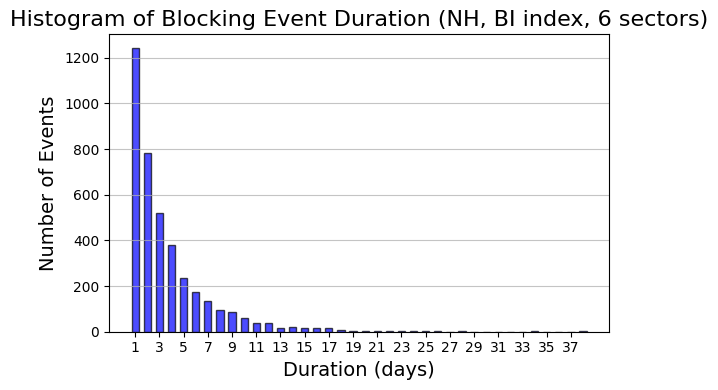

In [79]:
# instantaneous blocking frequency along the longitude
Blocking_freq2_ridge = np.zeros_like(Blocking_freq2)
for n in np.arange(len(BlockingTotal_date_ridge)):
    for d in np.arange(len(BlockingTotal_date_ridge[n])):
        date_index = Date.index(BlockingTotal_date_ridge[n][d])
        Blocking_freq2_ridge[date_index] += BlockingTotal_label_ridge[n][d].astype(float)

# define B index and calculate the sector blocking event frequency
# Sector blocking is then defined to occur if B is positive for at least 15 degree of longitude within the sector. 
# A sector blocking episode is said to occur if sector blocking occurs for at least 4 consecutive days.
# B index re-define: based on the label (Blocking_frq2_ridge), 
# if the blocking covers more than 10 degree of latitude (45-65N) then B = 1, else B = 0 at that longitude
B_index = np.zeros((nday, nlon))
lat_inds = np.where((lat_NH >= 45) & (lat_NH <= 65))[0]
for d in np.arange(nday):
    for lon_i in np.arange(nlon):
        lb = Blocking_freq2_ridge[d, :, lon_i]
        lb = lb[lat_inds]
        lon_inds = np.where(lb > 0)[0] # find the lon indices that have blocked over this lat range
        if len(lon_inds) > 10:
            B_index[d, lon_i] = 1
print(np.shape(B_index))

# then define the sector blocking event (should be no more than 1 event in one sector in one day)
sectordurationList = []
for (a, b) in [(270, 360), (0, 45), (45, 120), (90, 150), (150, 225), (210, 270)]:
    mask = (lon >= a) & (lon <= b)
    d = 0
    while d < nday:
        # judge if B_index[d, mask] > 0 covers more than 15 degree of longitude
        if np.count_nonzero(B_index[d, mask] > 0) * dlon >= 15:
            consec_days = 1
            d_next = d + 1
            # find the consecutive days
            while d_next < nday and np.count_nonzero(B_index[d_next, mask] > 0) * dlon >= 15:
                consec_days += 1
                d_next += 1
            sectordurationList.append(consec_days)
            d = d_next
        else:
            d += 1

print(len(sectordurationList))

# make the histogram of event persistence, 1 day per bin, y-axis is number of events (linear scale)
sectordurationList = np.array(sectordurationList)
plt.figure(figsize=(6,4))
plt.hist(sectordurationList, bins=np.arange(1, sectordurationList.max()+2)-0.5, alpha=0.7, color='blue', edgecolor='black', rwidth=0.6)
plt.xticks(np.arange(1, sectordurationList.max()+1, 2))
plt.xlabel('Duration (days)', fontsize=14)
plt.ylabel('Number of Events', fontsize=14)
plt.title(f'Histogram of Blocking Event Duration (NH, BI index, 6 sectors)', fontsize=16)
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

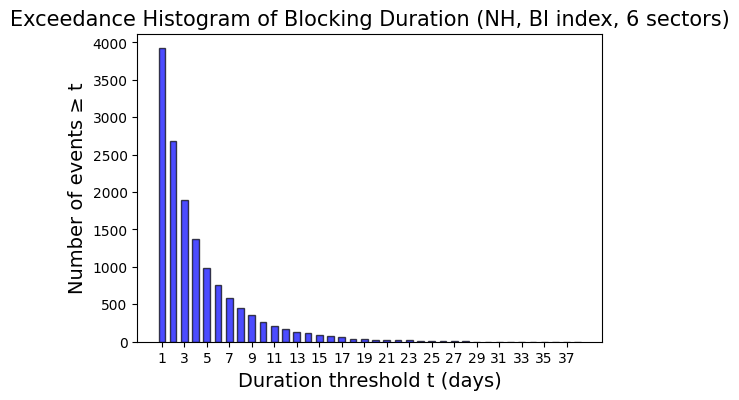

In [80]:
# a simple exceedance histogram
plt.figure(figsize=(6,4))
# ---------- Exceedance histogram ----------
max_d = sectordurationList.max()
# exceedance counts: N(t) = number of events with duration >= t
durations = np.arange(1, max_d + 1)
counts = np.array([np.sum(sectordurationList >= t) for t in durations])
plt.bar(durations, counts, width=0.6, alpha=0.7,
        color='blue', edgecolor='black', label='Exceedance counts')
plt.xticks(np.arange(1, max_d+1, 2))
plt.xlabel('Duration threshold t (days)', fontsize=14)
plt.ylabel('Number of events ≥ t', fontsize=14)
plt.title('Exceedance Histogram of Blocking Duration (NH, BI index, 6 sectors)', fontsize=15)
plt.show()

38


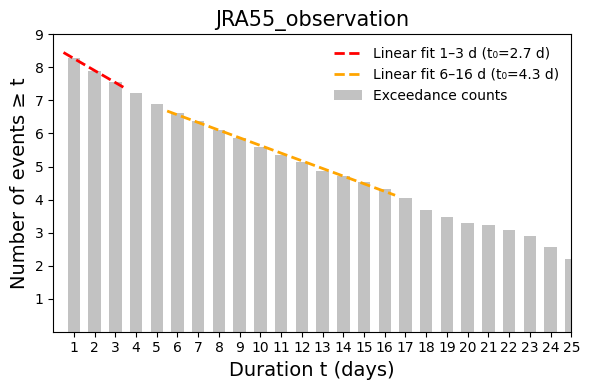

In [81]:
plt.figure(figsize=(6,4))

# ---------- Exceedance histogram ----------
max_d = sectordurationList.max()
print(max_d)

# exceedance counts: N(t) = number of events with duration >= t
durations = np.arange(1, max_d + 1)
counts = np.array([np.sum(sectordurationList >= t) for t in durations])

plt.bar(durations, counts, width=0.6, alpha=0.7,
        color='darkgray', edgecolor='None', label='Exceedance counts')

plt.xticks(np.arange(1, max_d+1, 2))
plt.xlabel('Duration t (days)', fontsize=14)
plt.ylabel('Number of events ≥ t', fontsize=14)
# plt.title('Exceedance Histogram of Blocking Duration (NH, BI index, 6 sectors)', fontsize=15)

# ---------- log-e y-axis ----------
ax = plt.gca()
ax.set_yscale('log', base=np.e)
ax.set_ylim(bottom=1)

ytop = ax.get_ylim()[1]
kmax = int(np.ceil(np.log(ytop)))
yticks = np.exp(np.arange(1, kmax + 1))
ax.set_yticks(yticks)
ax.set_yticklabels(np.arange(1, kmax + 1))  # show ln(N)
ax.set_title(f'{dtname}_observation', fontsize=15)
# plt.grid(axis='y', alpha=0.75, which='both')

# ---------- Linear-fit segments ----------
def fit_and_plot(dmin, dmax, color, label_prefix):
    sel = (durations >= dmin) & (durations <= dmax)
    x = durations[sel]
    y = counts[sel]
    m = y > 0
    x = x[m]; y = y[m]
    if x.size < 2:
        return
    b, a = np.polyfit(x, np.log(y), 1)  # ln-space linear fit
    xfit = np.array([dmin-0.5, dmax+0.5], dtype=float)
    yfit = np.exp(a + b * xfit)
    ax.plot(xfit, yfit, '--', lw=2, color=color,
            label=f'{label_prefix} {dmin}–{dmax} d (t₀={-1.0/b:.1f} d)')

fit_and_plot(1, 3,  'red',   'Linear fit')
fit_and_plot(6, 16, 'orange', 'Linear fit')
plt.xlim(0, 25)  
plt.xticks(np.arange(1, 26, 1))

ax.legend(frameon=False, fontsize=10, loc='best')
plt.tight_layout()
plt.savefig(f'./FINAL_figures/{dtname}_fig4a.png', dpi=300)
plt.show()